In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.othermod.betareg import BetaModel
from patsy import dmatrices, dmatrix
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_theme(style='whitegrid')

DATA_PATH = 'data/srcsc-2026-claims-workers-comp.xlsx'
freq_raw = pd.read_excel(DATA_PATH, sheet_name='freq')
sev_raw  = pd.read_excel(DATA_PATH, sheet_name='sev')
print(f'Frequency rows: {len(freq_raw):,}  |  Severity rows: {len(sev_raw):,}')

Frequency rows: 134,947  |  Severity rows: 1,917


# 1. Data Cleaning

In [3]:
def missing_summary(df, name):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    out  = pd.DataFrame({'missing': miss, 'pct_%': pct})
    out  = out[out['missing'] > 0].sort_values('missing', ascending=False)
    print(f'=== {name} ===')
    print(out.to_string())
    print()

missing_summary(freq_raw, 'Frequency dataset')
missing_summary(sev_raw,  'Severity dataset')

=== Frequency dataset ===
                         missing  pct_%
solar_system                 163   0.12
employment_type              158   0.12
station_id                   152   0.11
occupation                   142   0.11
worker_id                    141   0.10
policy_id                    133   0.10
gravity_level                107   0.08
experience_yrs               103   0.08
protective_gear_quality      103   0.08
accident_history_flag        101   0.07
base_salary                  101   0.07
hours_per_week                98   0.07
safety_training_index         97   0.07
exposure                      95   0.07
supervision_level             89   0.07
claim_count                   88   0.07
psych_stress_index            83   0.06

=== Severity dataset ===
                       missing  pct_%
accident_history_flag        4   0.21
claim_id                     3   0.16
injury_cause                 3   0.16
exposure                     3   0.16
psych_stress_index           3   0.16


In [4]:
VALID_SOLAR_SYSTEM = {
    'epsilon', 'helionis cluster', 'zeta'
}
VALID_OCCUPATION = {
    'administrator', 'drill operator', 'engineer', 'executive', 'maintenance staff', 'manager', 'planetary operations', 'safety officer', 'scientist', 'spacecraft operator', 'technology officer'
}
VALID_EMPLOYMENT = {
    'full-time', 'contract'
}
VALID_INJURY_TYPE = {
    'amputation', 'burns', 'cut lacerations', 'other', 'psychological', 'sprain, strain', 'stress'
}
VALID_INJURY_CAUSE = {
    'caught in machine', 'exposure', 'other', 'overextertion', 'stress/strain', 'vehicle accident', 'violence'
}
def is_valid_solar_system(s):
    return pd.notna(s) and str(s).strip().lower() in VALID_SOLAR_SYSTEM
def is_valid_occupation(s):
    return pd.notna(s) and str(s).strip().lower() in VALID_OCCUPATION
def is_valid_employment(s):
    return pd.notna(s) and str(s).strip().lower() in VALID_EMPLOYMENT
def is_valid_injury_type(s):
    return pd.notna(s) and str(s).strip().lower() in VALID_INJURY_TYPE
def is_valid_injury_cause(s):
    return pd.notna(s) and str(s).strip().lower() in VALID_INJURY_CAUSE

In [5]:
# Function clean frequency dataset. 

def clean_freq(df):
    # Active filter flags 
    flags = ['flag_invalid_solar_system', 'flag_out_of_range', 'flag_invalid_psi', 'flag_invalid_hpw', 'flag_invalid_sti', 'flag_invalid_pgq', 'flag_invalid_cc']
    
    # List of important variables. Data record will be dropped if these are blank.
    mvars = ['policy_id', 'worker_id', 'station_id', 'experience_yrs', 'accident_history_flag', 'psych_stress_index',
             'hours_per_week', 'supervision_level', 'gravity_level', 'safety_training_index', 'protective_gear_quality', 'exposure']
    
    n0 = len(df)
    df = df.copy()

    df['flag_invalid_solar_system'] = ~df['solar_system'].map(is_valid_solar_system)

    # Enforced value ranges, taken from the Data Dictionary
    df['flag_out_of_range'] = (
        (~df['experience_yrs'].between(0.2, 40)) |
        (~df['accident_history_flag'].between(0, 1)) |
        (~df['supervision_level'].between(0, 1)) |
        (~df['gravity_level'].between(0.75, 1.5))|
        (~df['exposure'].between(0, 1))
    )

    # psych_stress_index must be an integer in {1,2,3,4,5}
    df['flag_invalid_psi'] = (
        ~df['psych_stress_index'].between(1, 5) |
        (df['psych_stress_index'] != df['psych_stress_index'].round())
    )
   # hours_per_week must be an integer in {20,25,30,35,40} #maybe take absolute of the hours per week first then adjust to 20-40- modify code
    df['flag_invalid_hpw'] = (
        ~df['hours_per_week'].between(20, 40) |
        (df['hours_per_week'] != df['hours_per_week'].round())
    )
    # safety_training_index must be an integer in {1,2,3,4,5}
    df['flag_invalid_sti'] = (
        ~df['safety_training_index'].between(1, 5) |
        (df['safety_training_index'] != df['safety_training_index'].round())
    )
      # protective_gear_quality must be an integer in {1,2,3,4,5}
    df['flag_invalid_pgq'] = (
        ~df['protective_gear_quality'].between(1, 5) |
        (df['protective_gear_quality'] != df['protective_gear_quality'].round())
    )

    # claim_count must be in {0,1,2}
    df['flag_invalid_cc'] = (
        (df['claim_count'] != df['claim_count'].round()) |
        (~df['claim_count'].between(0, 2))
    )
    print('=== Frequency data flagging ===')
    for f in flags:
        print(f'  {f}: {df[f].sum():,}')
    any_flag = df[flags].any(axis=1)
    print(f'  Any flag: {any_flag.sum():,}')

    df_clean = df[~any_flag].copy()
    df_clean = df_clean.dropna(subset=mvars)
    df_clean['claim_count'] = df_clean['claim_count'].astype(int)

    print(f'  Rows: {n0:,} -> {len(df_clean):,}  ({len(df_clean)/n0*100:.1f}%)')
    return df_clean

freq_clean = clean_freq(freq_raw)

freq_clean['employment_type'] = (
    freq_clean['employment_type']
    .str.strip()
    .str.lower()
)
freq_clean = freq_clean[freq_clean['employment_type'].apply(is_valid_employment)]

=== Frequency data flagging ===
  flag_invalid_solar_system: 326
  flag_out_of_range: 1,277
  flag_invalid_psi: 285
  flag_invalid_hpw: 302
  flag_invalid_sti: 286
  flag_invalid_pgq: 315
  flag_invalid_cc: 89
  Any flag: 2,861
  Rows: 134,947 -> 131,665  (97.6%)


In [6]:
def clean_sev(df):
    
    # Active filter flags
    flags = ['flag_invalid_solar_system', 'flag_out_of_range', 'flag_invalid_psi', 'flag_invalid_hpw', 'flag_invalid_sti', 'flag_invalid_pgq','flag_invalid_sr']
    
    # List of important variables. Data record will be dropped if these are blank.
    mvars = ['policy_id', 'worker_id', 'station_id', 'experience_yrs', 'accident_history_flag', 'psych_stress_index',
             'hours_per_week', 'supervision_level', 'gravity_level', 'safety_training_index', 'protective_gear_quality', 'exposure', 'base_salary']
    
    
    n0 = len(df)
    df = df.copy()
    df['severity_ratio'] = df['claim_amount'] / df['base_salary']

    df['flag_invalid_solar_system'] = ~df['solar_system'].map(is_valid_solar_system)

    # Enforced value ranges from Data Dictionary
    df['flag_out_of_range'] = (
        (~df['experience_yrs'].between(0.2, 40)) |
        (~df['accident_history_flag'].between(0, 1)) |
        (~df['supervision_level'].between(0, 1)) |
        (~df['gravity_level'].between(0.75, 1.5))|
        (~df['exposure'].between(0, 1)) |
        (~df['base_salary'].between(20000, 130000))
    )

    # psych_stress_index must be an integer in {1,2,3,4,5}
    df['flag_invalid_psi'] = (
        ~df['psych_stress_index'].between(1, 5) |
        (df['psych_stress_index'] != df['psych_stress_index'].round())
    )
   # hours_per_week must be an integer in {20,25,30,35,40} #maybe take absolute of the hours per week first then adjust to 20-40- modify code
    df['flag_invalid_hpw'] = (
        ~df['hours_per_week'].between(20, 40) |
        (df['hours_per_week'] != df['hours_per_week'].round())
    )
    # safety_training_index must be an integer in {1,2,3,4,5}
    df['flag_invalid_sti'] = (
        ~df['safety_training_index'].between(1, 5) |
        (df['safety_training_index'] != df['safety_training_index'].round())
    )
      # protective_gear_quality must be an integer in {1,2,3,4,5}
    df['flag_invalid_pgq'] = (
        ~df['protective_gear_quality'].between(1, 5) |
        (df['protective_gear_quality'] != df['protective_gear_quality'].round())
    )


    df['flag_invalid_sr'] = ~(df['severity_ratio'] > 0) | ~(df['severity_ratio'] < 1)

    print('=== Severity data flagging ===')
    for f in flags:
        print(f'  {f}: {df[f].sum():,}')
    any_flag = df[flags].any(axis=1)
    print(f'  Any flag: {any_flag.sum():,}')

    df_clean = df[~any_flag].copy()
    df_clean = df_clean.dropna(subset=mvars)

    print(f'  Rows: {n0:,} -> {len(df_clean):,}  ({len(df_clean)/n0*100:.1f}%)')
    return df_clean

sev_clean = clean_sev(sev_raw)

sev_clean["injury_type"] = (
    sev_clean["injury_type"]
    .str.lower()
    .str.strip()
    .str.replace(r"_.*", "", regex=True)
)
sev_clean["occupation"] = (
    sev_clean["occupation"]
    .str.lower()
    .str.strip()
    .str.replace(r"_.*", "", regex=True)
)
sev_clean["injury_cause"] = (
    sev_clean["injury_cause"]
    .str.lower()
    .str.strip()
    .str.replace(r"_.*", "", regex=True)
)

=== Severity data flagging ===
  flag_invalid_solar_system: 2
  flag_out_of_range: 23
  flag_invalid_psi: 8
  flag_invalid_hpw: 5
  flag_invalid_sti: 4
  flag_invalid_pgq: 0
  flag_invalid_sr: 104
  Any flag: 142
  Rows: 1,917 -> 1,770  (92.3%)


# 2. Exploratory Data Analysis (EDA)

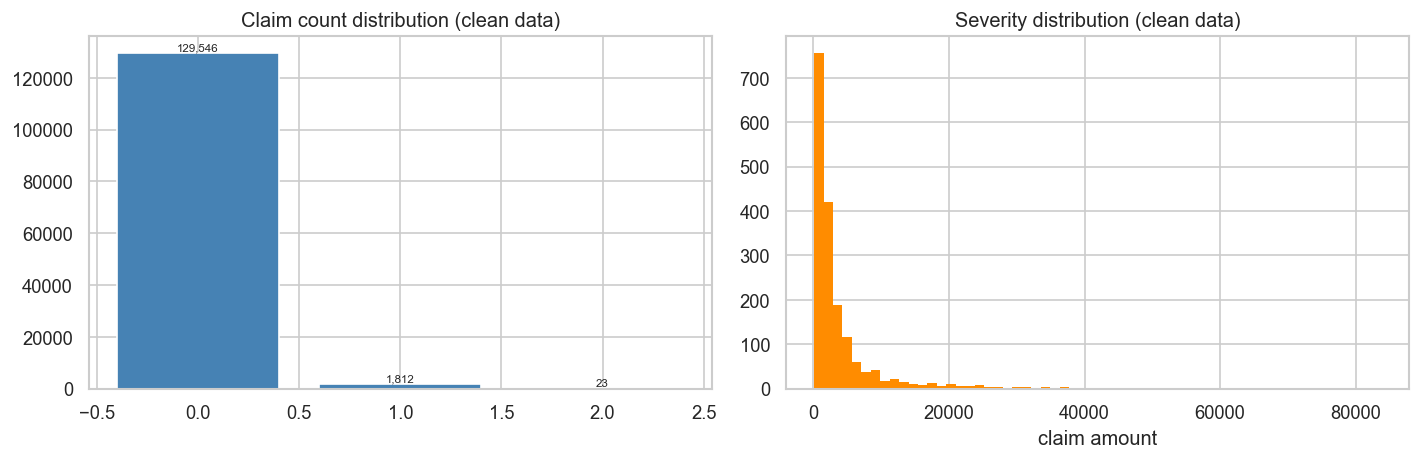

Clean frequency -- claim_count: {'count': 131381.0, 'mean': 0.014142075338138696, 'std': 0.11955046030507224, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 2.0}
Clean severity -- claim_amount:   {'count': 1770.0, 'mean': 3987.9684350282487, 'std': 6763.289793405017, 'min': 120.76, '25%': 952.355, '50%': 1828.185, '75%': 3894.69, 'max': 83660.96}


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc = freq_clean['claim_count'].value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color='steelblue', edgecolor='white')
axes[0].set_title('Claim count distribution (clean data)')
for val in vc.index:
    axes[0].annotate(f'{vc[val]:,}', xy=(val, vc[val]), ha='center', va='bottom', fontsize=7)
axes[1].hist(sev_clean['claim_amount'], bins=60, color='darkorange', edgecolor='none')
axes[1].set_title('Severity distribution (clean data)')
axes[1].set_xlabel('claim amount')
plt.tight_layout(); plt.show()

print('Clean frequency -- claim_count:', freq_clean['claim_count'].describe().to_dict())
print('Clean severity -- claim_amount:  ', sev_clean['claim_amount'].describe().to_dict())

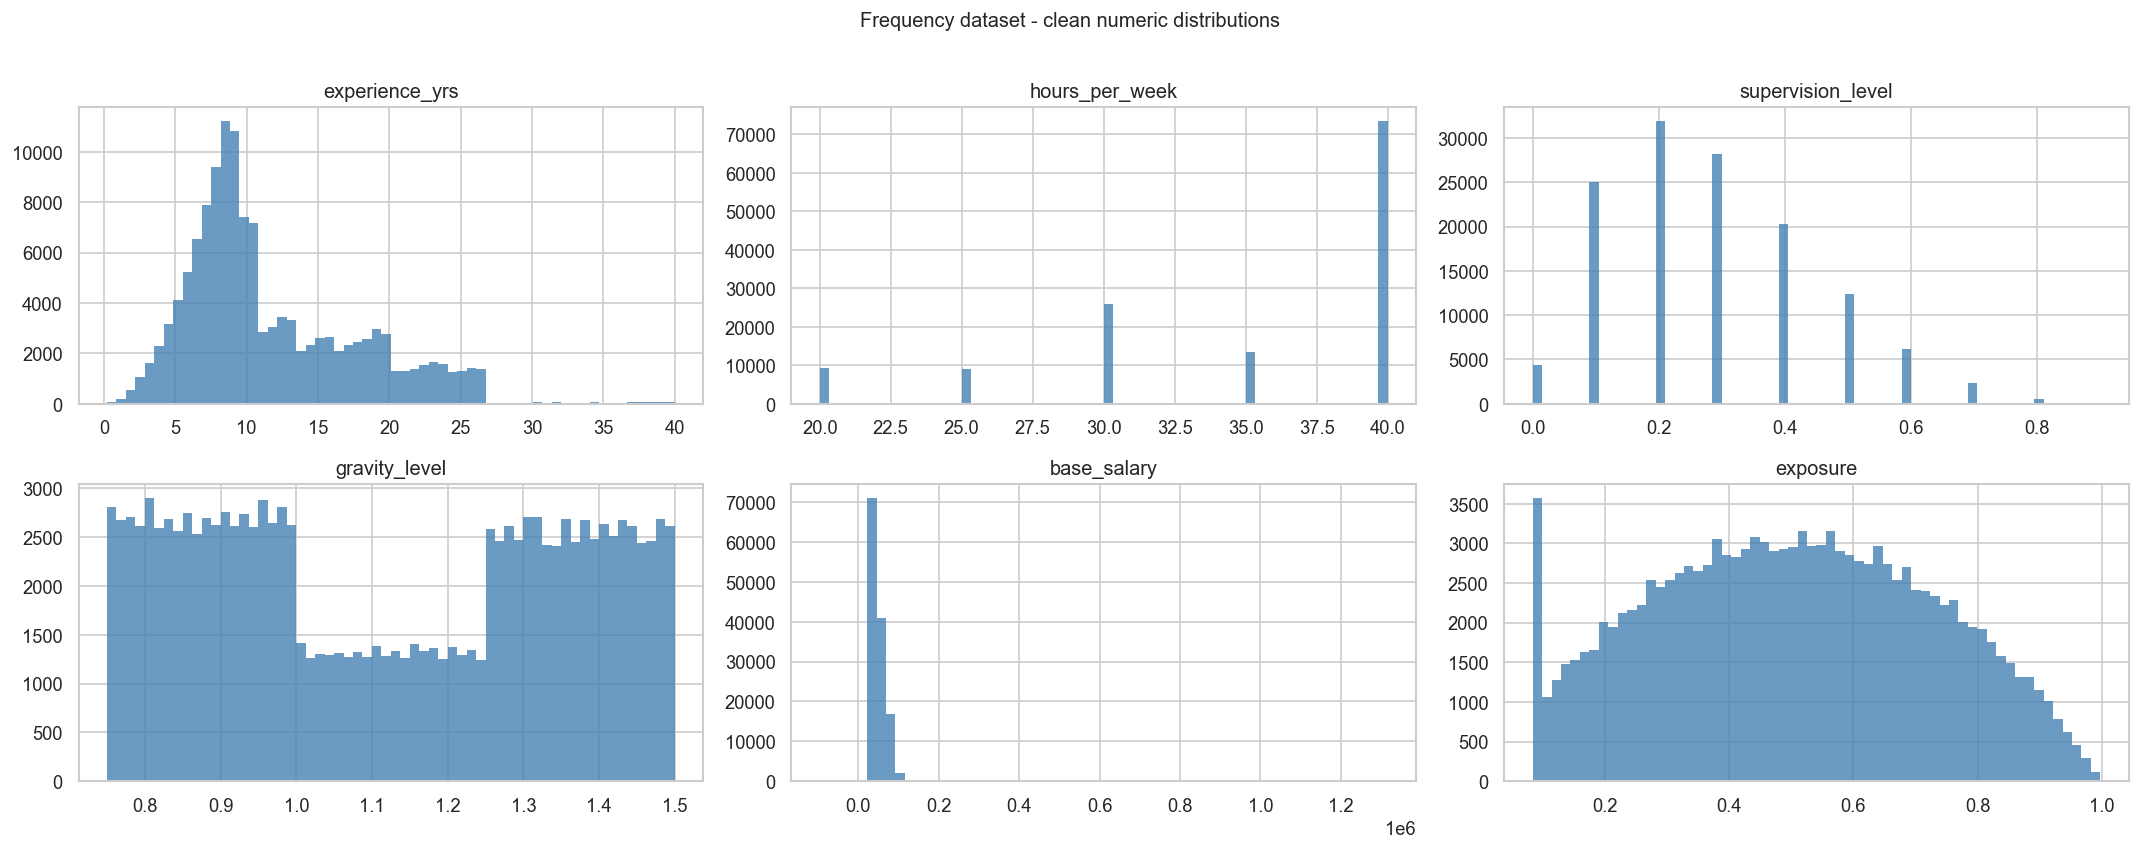

In [8]:
num_cols = ['experience_yrs', 'hours_per_week', 'supervision_level', 'gravity_level',
            'base_salary', 'exposure']

fig, axes = plt.subplots(2, 3, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    data = freq_clean[col].dropna()
    axes[i].hist(data, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col)
plt.suptitle('Frequency dataset - clean numeric distributions', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

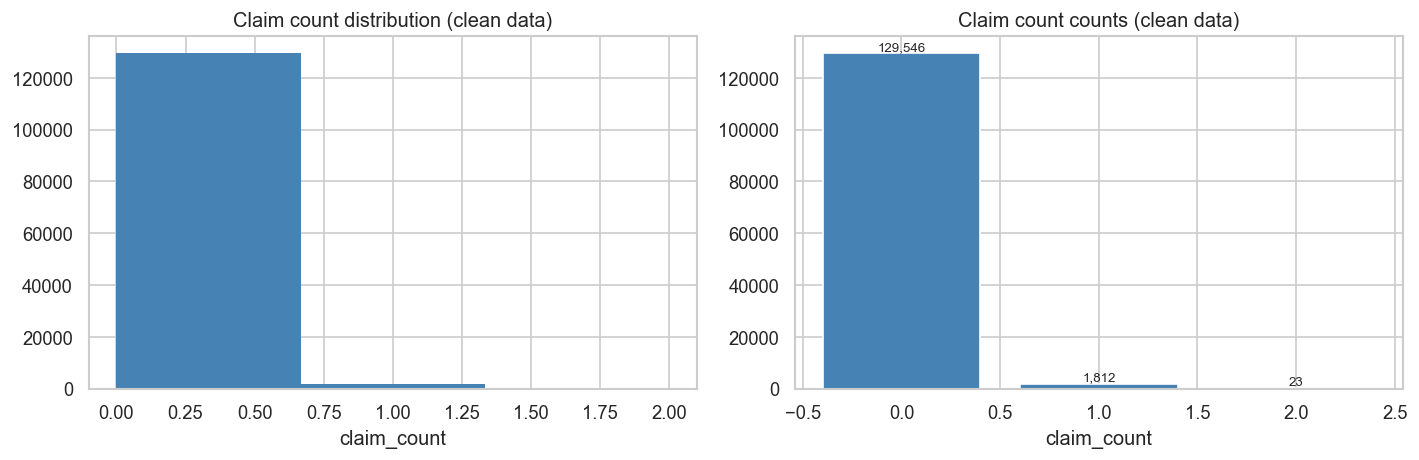

Claim count: {'count': 131381.0, 'mean': 0.014142075338138696, 'std': 0.11955046030507224, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 2.0}


In [9]:
cc = freq_clean['claim_count']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(cc, bins=cc.max()+1, color='steelblue', edgecolor='none')
axes[0].set_title('Claim count distribution (clean data)')
axes[0].set_xlabel('claim_count')

vc = cc.value_counts().sort_index()
axes[1].bar(vc.index, vc.values, color='steelblue', edgecolor='white')
for val in vc.index:
    axes[1].annotate(f'{vc[val]:,}', xy=(val, vc[val]), ha='center', va='bottom', fontsize=8)
axes[1].set_title('Claim count counts (clean data)')
axes[1].set_xlabel('claim_count')
plt.tight_layout()
plt.show()

print(f'Claim count: {cc.describe().to_dict()}')

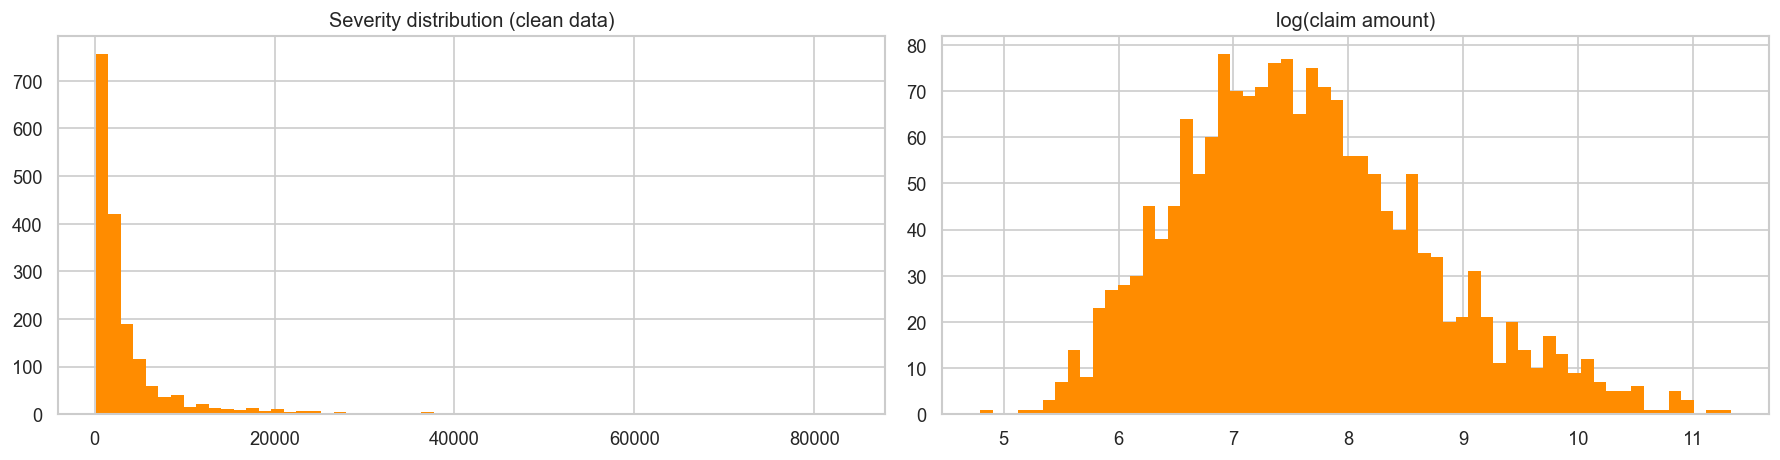

Severity : n=1,770  mean=3987.9684  median=1828.1850


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].hist(sev_clean['claim_amount'], bins=60, color='darkorange', edgecolor='none')
axes[0].set_title('Severity distribution (clean data)')
axes[1].hist(np.log(sev_clean['claim_amount']), bins=60, color='darkorange', edgecolor='none')
axes[1].set_title('log(claim amount)')
plt.tight_layout()
plt.show()

print(f'Severity : n={len(sev_clean['claim_amount']):,}  mean={sev_clean['claim_amount'].mean():.4f}  median={sev_clean['claim_amount'].median():.4f}')

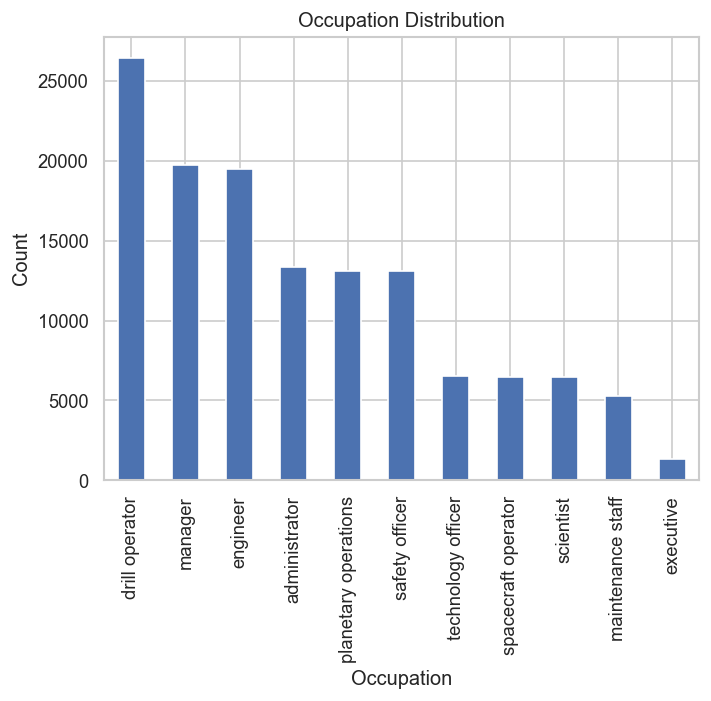

In [11]:

freq_clean['occupation'] = freq_clean['occupation'].str.lower().str.split('_').str[0]
freq_clean['occupation'].unique()
freq_clean['occupation'].value_counts().plot(kind='bar')

plt.title("Occupation Distribution")
plt.xlabel("Occupation")
plt.ylabel("Count")

plt.show()



Text(0, 0.5, 'Count')

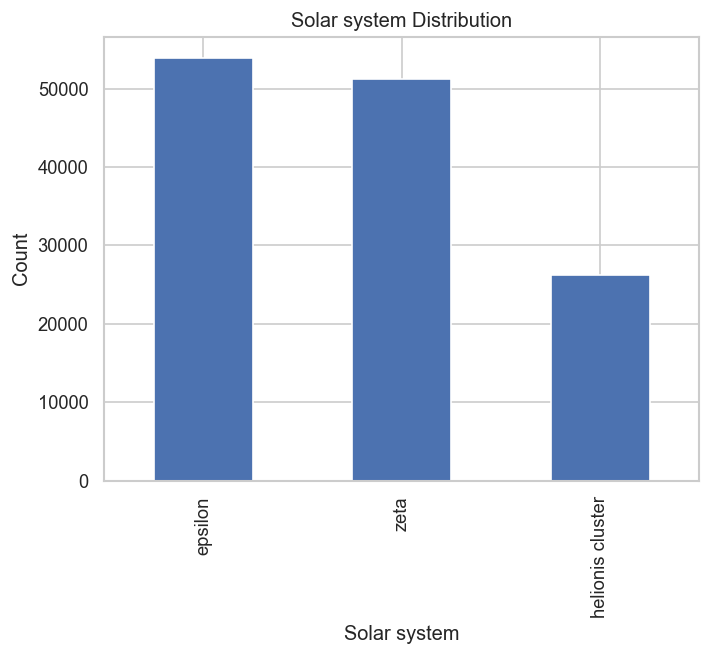

In [12]:
freq_clean['solar_system'] = freq_clean['solar_system'].str.lower().str.split('_').str[0]
freq_clean['solar_system'].value_counts().plot(kind='bar')
plt.title("Solar system Distribution")
plt.xlabel("Solar system")
plt.ylabel("Count")

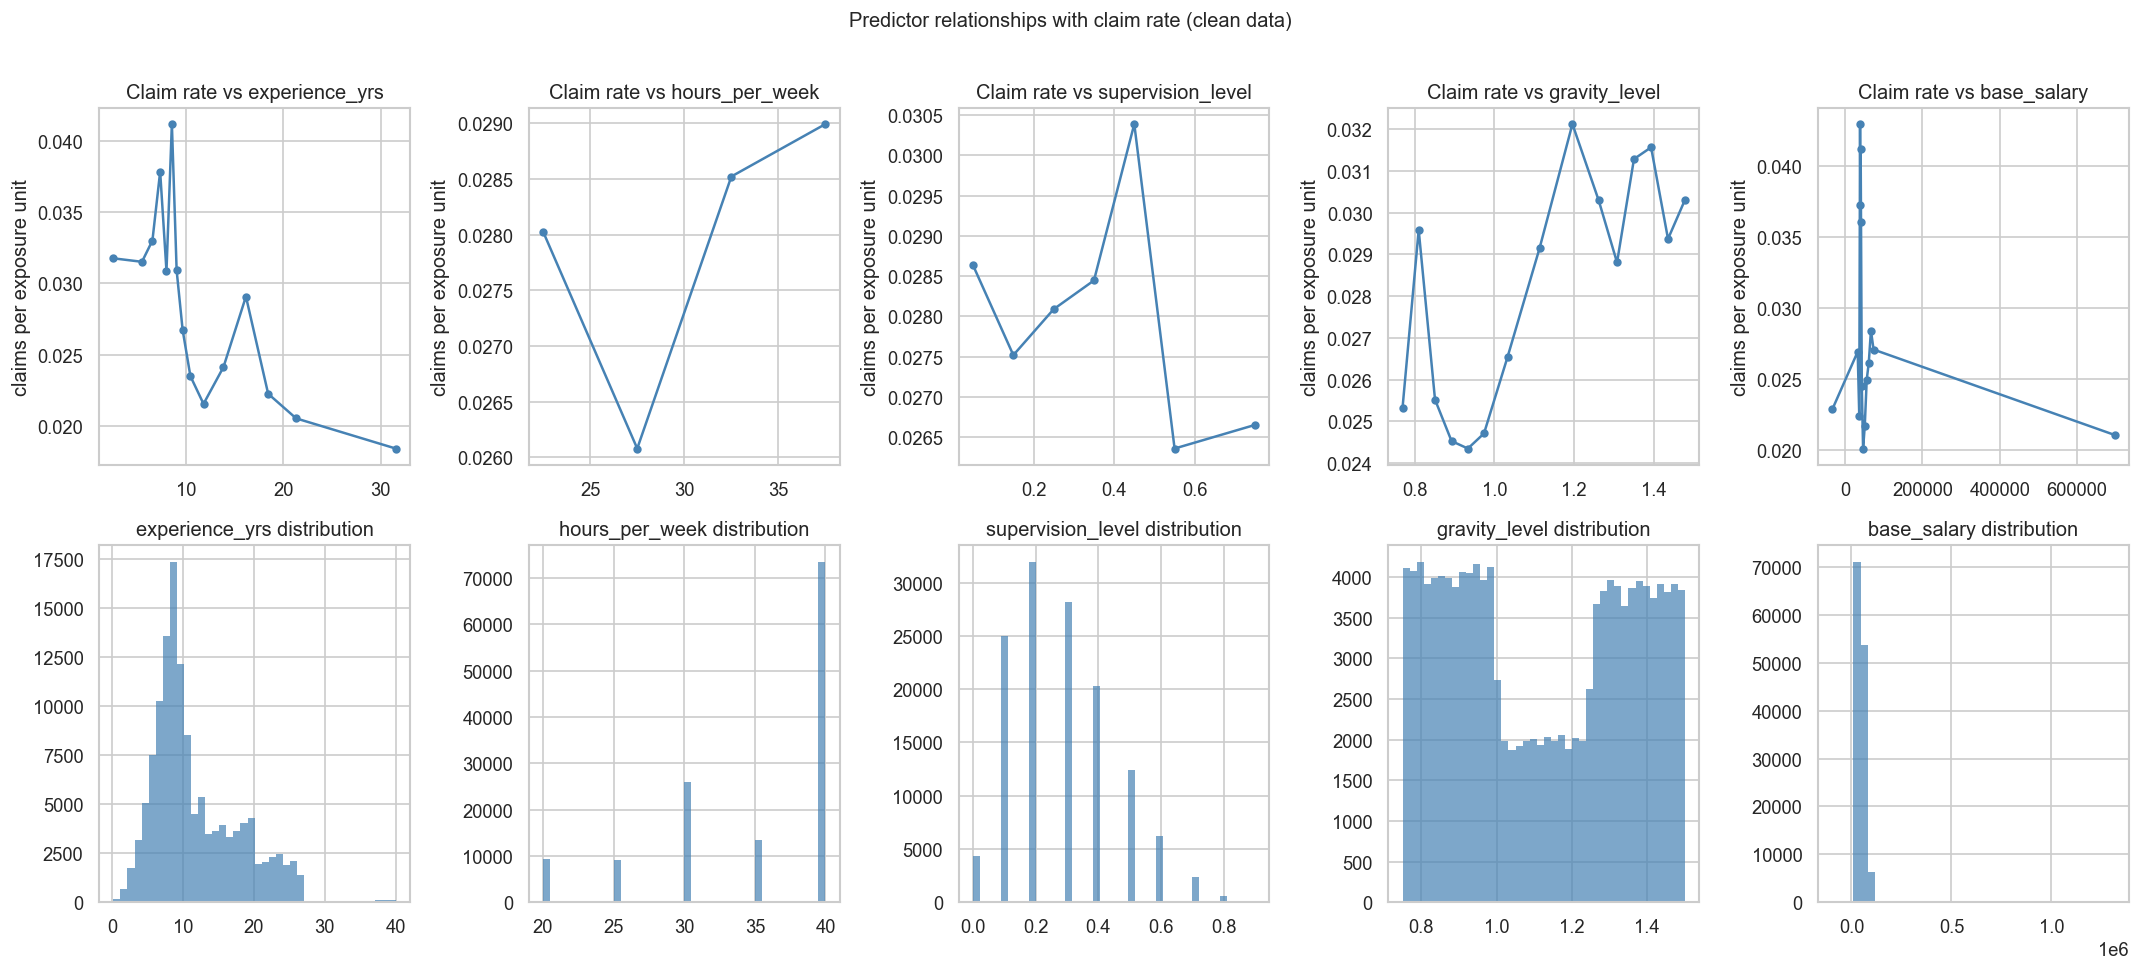

In [13]:
cont_preds = ['experience_yrs', 'hours_per_week', 'supervision_level', 'gravity_level', 'base_salary']
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, col in enumerate(cont_preds):
    sub = freq_clean.copy()
    sub['bin'] = pd.qcut(sub[col], q=15, duplicates='drop')
    grp = sub.groupby('bin', observed=True)[['claim_count', 'exposure']].sum()
    grp['claim_rate'] = grp['claim_count'] / grp['exposure']
    grp['mid'] = grp.index.map(lambda x: x.mid)
    axes[0, i].plot(grp['mid'], grp['claim_rate'], 'o-', color='steelblue', ms=4)
    axes[0, i].set_title(f'Claim rate vs {col}')
    axes[0, i].set_ylabel('claims per exposure unit')
    axes[1, i].hist(freq_clean[col], bins=40, color='steelblue', edgecolor='none', alpha=0.7)
    axes[1, i].set_title(f'{col} distribution')
plt.suptitle('Predictor relationships with claim rate (clean data)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

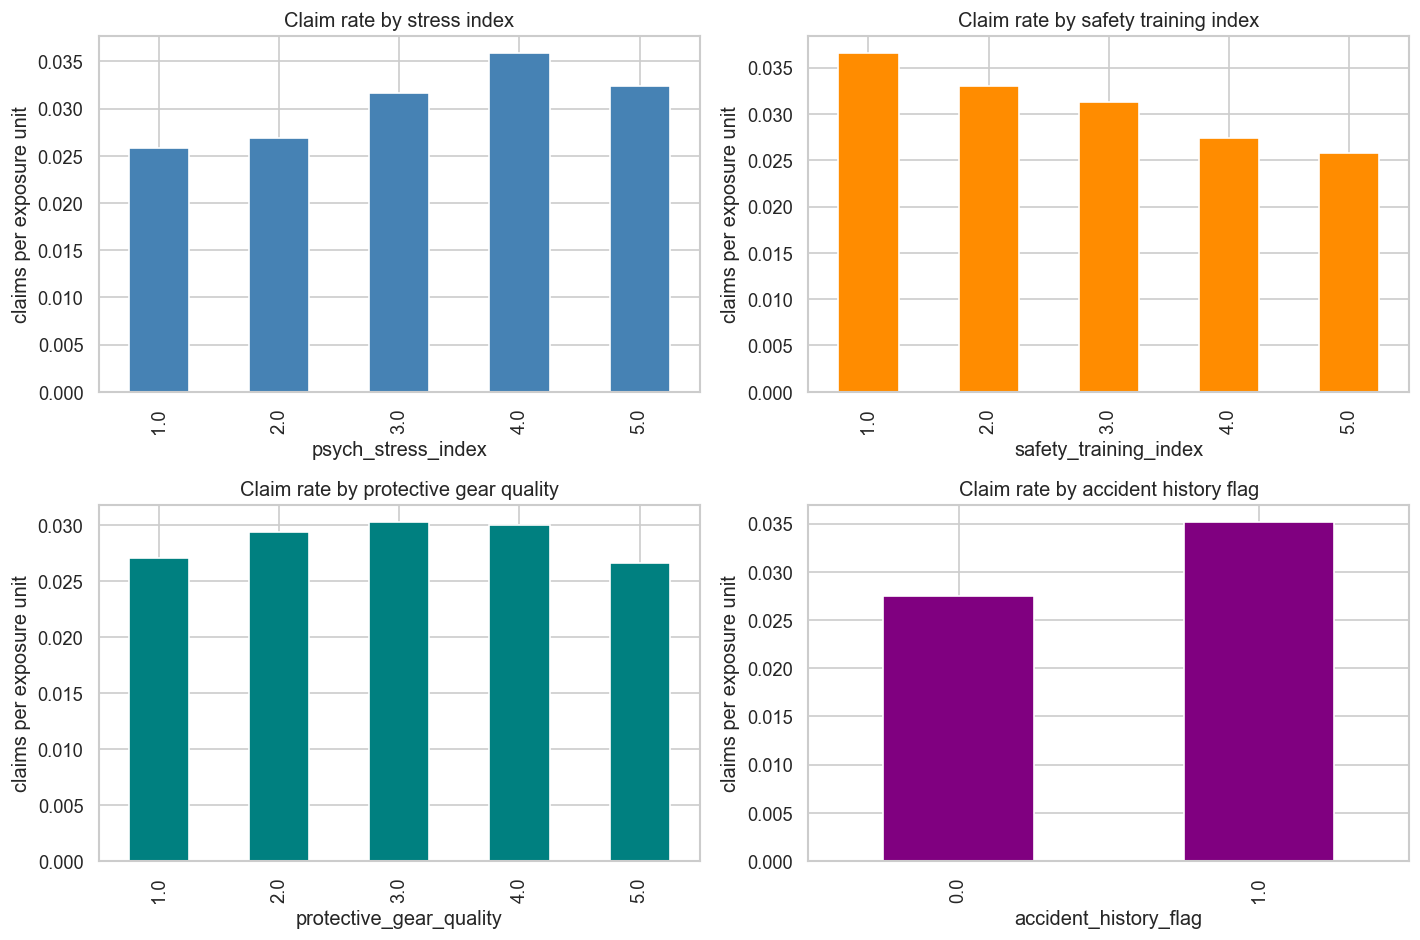

In [14]:
def agg_rate(df, group_col):
    g = df.groupby(group_col)[['claim_count', 'exposure']].sum()
    g['claim_rate'] = g['claim_count'] / g['exposure']
    return g['claim_rate']

stress_rate = agg_rate(freq_clean, 'psych_stress_index')
training_rate = agg_rate(freq_clean, 'safety_training_index')
gear_rate = agg_rate(freq_clean, 'protective_gear_quality')
accident_rate = agg_rate(freq_clean, 'accident_history_flag')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

stress_rate.plot.bar(ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Claim rate by stress index')
axes[0,0].set_ylabel('claims per exposure unit')

training_rate.plot.bar(ax=axes[0,1], color='darkorange', edgecolor='white')
axes[0,1].set_title('Claim rate by safety training index')
axes[0,1].set_ylabel('claims per exposure unit')

gear_rate.plot.bar(ax=axes[1,0], color='teal', edgecolor='white')
axes[1,0].set_title('Claim rate by protective gear quality')
axes[1,0].set_ylabel('claims per exposure unit')

accident_rate.plot.bar(ax=axes[1,1], color='purple', edgecolor='white')
axes[1,1].set_title('Claim rate by accident history flag')
axes[1,1].set_ylabel('claims per exposure unit')

plt.tight_layout()
plt.show()



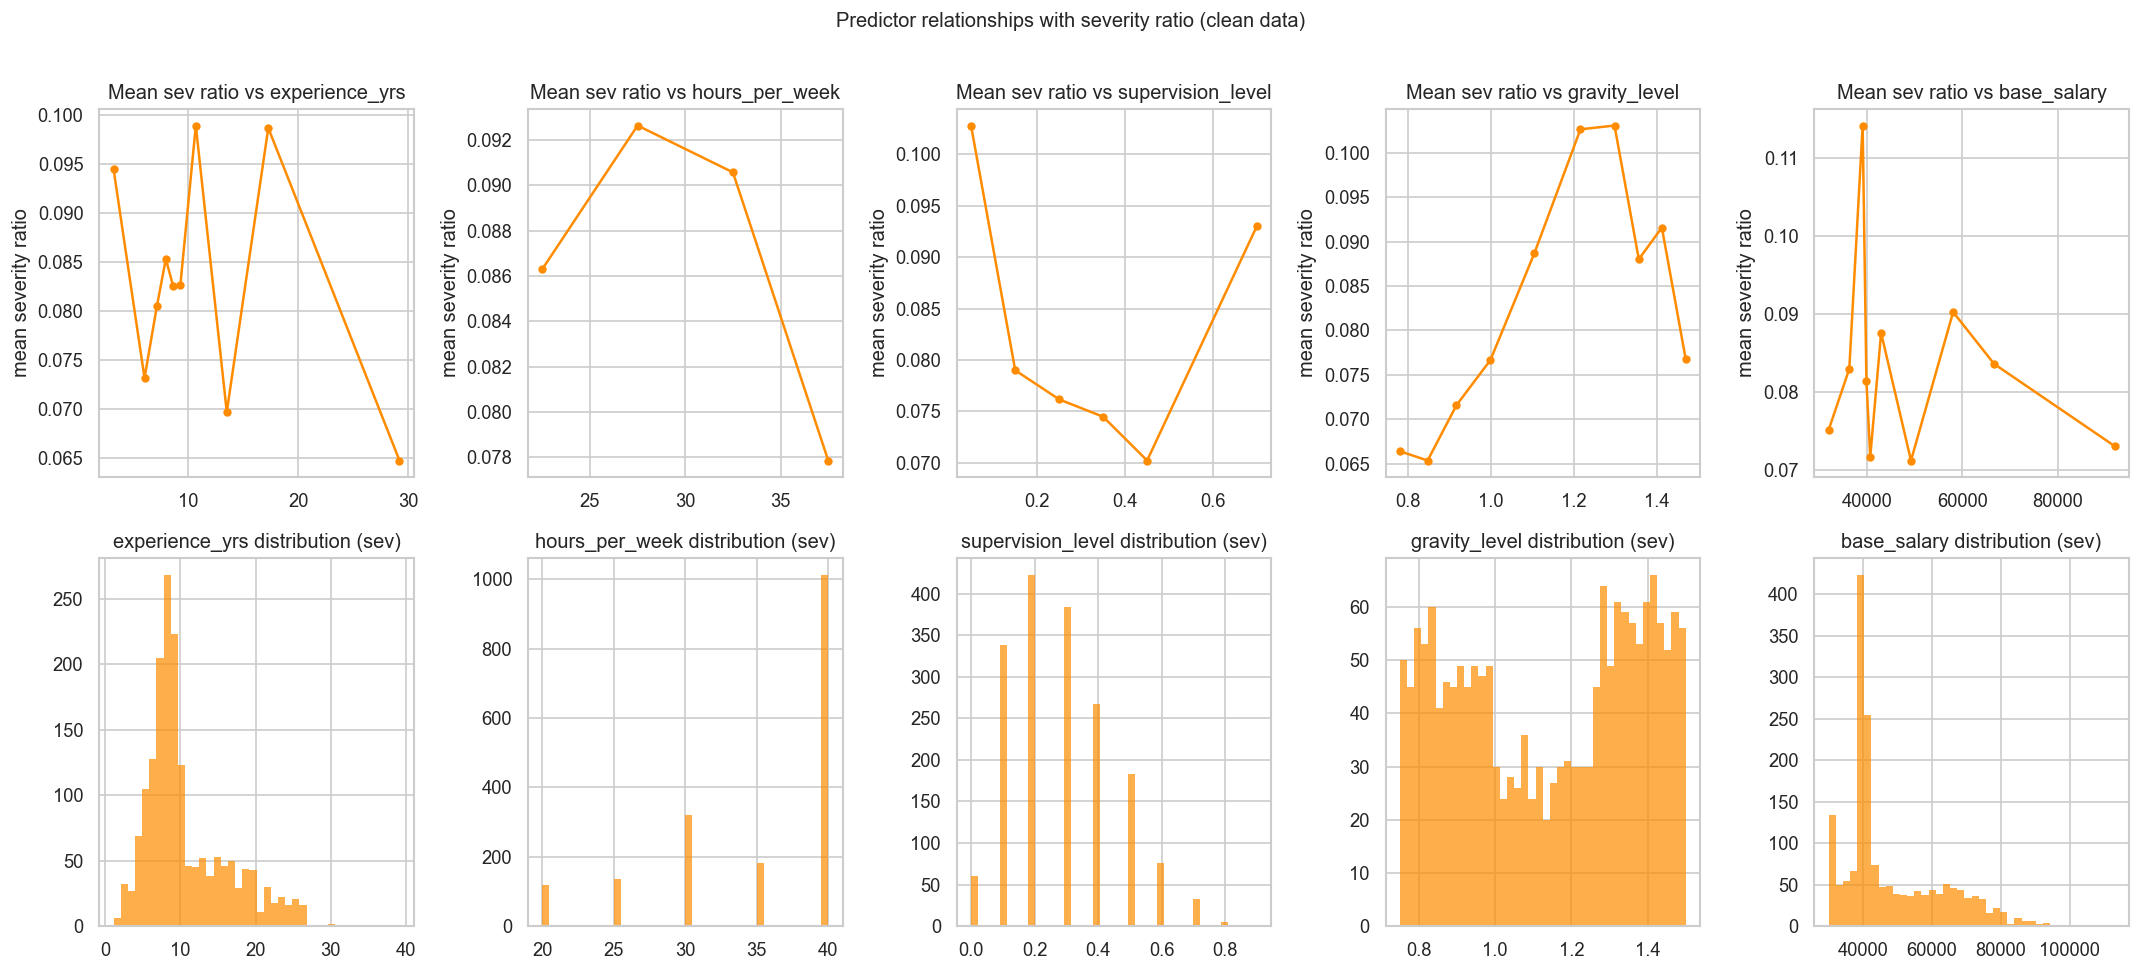

In [15]:
cont_preds = ['experience_yrs', 'hours_per_week', 'supervision_level', 'gravity_level', 'base_salary']
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, col in enumerate(cont_preds):
    sub = sev_clean.copy()
    sub['bin'] = pd.qcut(sub[col], q=10, duplicates='drop')
    grp = sub.groupby('bin', observed=True)['severity_ratio'].mean().reset_index()
    grp['mid'] = grp['bin'].apply(lambda x: x.mid)
    axes[0, i].plot(grp['mid'], grp['severity_ratio'], 'o-', color='darkorange', ms=4)
    axes[0, i].set_title(f'Mean sev ratio vs {col}')
    axes[0, i].set_ylabel('mean severity ratio')
    axes[1, i].hist(sev_clean[col], bins=40, color='darkorange', edgecolor='none', alpha=0.7)
    axes[1, i].set_title(f'{col} distribution (sev)')
plt.suptitle('Predictor relationships with severity ratio (clean data)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# 3. Frequency model - Poisson

In [16]:
model_pois = smf.glm(
    formula="""
    claim_count ~ solar_system + occupation + employment_type +
    experience_yrs + accident_history_flag + psych_stress_index +
    hours_per_week + supervision_level + gravity_level +
    safety_training_index + protective_gear_quality + base_salary
    """,
    data=freq_clean,
    family=sm.families.Poisson(),
    offset=np.log(freq_clean['exposure'])
).fit()
print(model_pois.summary())

dispersion = model_pois.deviance / model_pois.df_resid
print("Dispersion:", dispersion)


                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:               131142
Model:                            GLM   Df Residuals:                   131119
Model Family:                 Poisson   Df Model:                           22
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9392.4
Date:                Thu, 26 Mar 2026   Deviance:                       15103.
Time:                        21:48:36   Pearson chi2:                 1.30e+05
No. Iterations:                     7   Pseudo R-squ. (CS):           0.002494
Covariance Type:            nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

In [17]:
model_pois = smf.glm(
    formula="""
    claim_count ~ occupation  + accident_history_flag + psych_stress_index + safety_training_index
    """,
    data=freq_clean,
    family=sm.families.Poisson(),
    offset=np.log(freq_clean['exposure'])
).fit()
print(model_pois.summary())

# to find parameter lambda : exponentiated coefficients for multiplicative interpretation
coef_df = pd.DataFrame({
    'coef': model_pois.params,
    'exp(coef)': np.exp(model_pois.params),
    'p_value': model_pois.pvalues
}).sort_values('p_value')

print('\nExponentiated coefficients (multiplicative effect on expected claim count):')
print(coef_df.to_string())

# -----------------------------
# Dispersion check
# -----------------------------
dispersion = model_pois.deviance / model_pois.df_resid

print(f"Model Deviance: {model_pois.deviance:.4f}")
print(f"Residual DF: {model_pois.df_resid}")
print(f"Dispersion (Deviance / DF): {dispersion:.4f}")

pearson_dispersion = sum(model_pois.resid_pearson**2) / model_pois.df_resid
print(f"Pearson Dispersion: {pearson_dispersion:.4f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:               131240
Model:                            GLM   Df Residuals:                   131226
Model Family:                 Poisson   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9404.3
Date:                Thu, 26 Mar 2026   Deviance:                       15124.
Time:                        21:48:36   Pearson chi2:                 1.30e+05
No. Iterations:                     7   Pseudo R-squ. (CS):           0.002397
Covariance Type:            nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

# 4. Severity model - log normal

In [18]:
sev_clean["claim_amount"].skew()


sev_clean["log_claim"] = np.log(sev_clean["claim_amount"])

import statsmodels.formula.api as smf
import statsmodels.api as sm

model_lognormal = smf.ols(
    formula="""
    log_claim ~ occupation + psych_stress_index + gravity_level + safety_training_index + protective_gear_quality
    """,
    data=sev_clean
).fit()

print(model_lognormal.summary())

#parameters
mu = sev_clean["log_claim"].mean()
sigma2 = sev_clean["log_claim"].var()

print("mu:", mu)
print("sigma^2:", sigma2)



                            OLS Regression Results                            
Dep. Variable:              log_claim   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     36.67
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.47e-87
Time:                        21:48:36   Log-Likelihood:                -2417.8
No. Observations:                1770   AIC:                             4866.
Df Residuals:                    1755   BIC:                             4948.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

# 5. Pricing: Premiums = Expected Frequency × Expected Severity

In [19]:
pricing_df = freq_clean

#predict freq


pricing_df['pred_claims'] = model_pois.predict(
    pricing_df,
    offset=np.log(pricing_df['exposure'])
)

pricing_df['freq_rate'] = pricing_df['pred_claims'] / pricing_df['exposure']


#predict sev
sigma2 = model_lognormal.mse_resid

pricing_df['pred_severity'] = np.exp(
    model_lognormal.predict(pricing_df) + sigma2/2
)

#pure
pricing_df['pure_premium'] = (
    pricing_df['freq_rate'] *
    pricing_df['pred_severity']
)
#add loadings
expense_loading = 0.25
profit_loading = 0.10

pricing_df['technical_premium'] = (
    pricing_df['pure_premium'] *
    (1 + expense_loading + profit_loading)
)

pricing_summary = pricing_df.groupby(
    ['solar_system','gravity_level']
).agg(
    pure_premium=('pure_premium','mean'),
    technical_premium=('technical_premium','mean')
).reset_index()

print(pricing_summary)


    solar_system  gravity_level  pure_premium  technical_premium
0        epsilon          0.750     81.750966         110.363804
1        epsilon          0.751     86.370728         116.600483
2        epsilon          0.752     90.562110         122.258848
3        epsilon          0.753    100.168699         135.227743
4        epsilon          0.754     83.937151         113.315154
..           ...            ...           ...                ...
748         zeta          1.496    134.558796         181.654374
749         zeta          1.497    108.098899         145.933513
750         zeta          1.498    120.610622         162.824340
751         zeta          1.499    112.661853         152.093502
752         zeta          1.500    129.195368         174.413746

[753 rows x 4 columns]


In [23]:
#pricing by solar systemm

pricing_solar = pricing_df.groupby('solar_system').agg(
    avg_pure_premium=('pure_premium','mean'),
    avg_technical_premium=('technical_premium','mean'),
    avg_freq=('freq_rate','mean'),
    avg_severity=('pred_severity','mean')
).reset_index()
print("\nPricing by Solar System")

print(pricing_solar)

# pricing by occupation
pricing_occupation = pricing_df.groupby('occupation').agg(
    avg_pure_premium=('pure_premium','mean'),
    avg_technical_premium=('technical_premium','mean'),
    avg_freq=('freq_rate','mean'),
    avg_severity=('pred_severity','mean')
).reset_index()
print("\nPricing by Occupation")

print(pricing_occupation)



# -----------------------------
# Indicative rating table
# -----------------------------
pricing_summary = pricing_df.groupby(
    ['occupation', 'psych_stress_index']
).agg(
    expected_frequency=('freq_rate', 'mean'),
    expected_severity=('pred_severity', 'mean'),
    pure_premium=('pure_premium', 'mean'),
    technical_premium=('technical_premium', 'mean')
).reset_index()

# Round for readability
pricing_summary[['expected_frequency','expected_severity','pure_premium','technical_premium']] = \
    pricing_summary[['expected_frequency','expected_severity','pure_premium','technical_premium']].round(2)


print(pricing_summary)


Pricing by Solar System
       solar_system  avg_pure_premium  avg_technical_premium  avg_freq  \
0           epsilon         91.553525             123.597258  0.028280   
1  helionis cluster        115.827722             156.367424  0.028287   
2              zeta        109.517141             147.848140  0.028227   

   avg_severity  
0   3074.582938  
1   3901.334148  
2   3687.783616  

Pricing by Occupation
              occupation  avg_pure_premium  avg_technical_premium  avg_freq  \
0          administrator         43.749702              59.062097  0.015402   
1         drill operator        151.673121             204.758714  0.047668   
2               engineer        148.914422             201.034470  0.029822   
3              executive         87.499268             118.124012  0.014954   
4      maintenance staff         77.323908             104.387276  0.031454   
5                manager         82.777978             111.750270  0.018598   
6   planetary operations      

In [28]:
# sort technical premiums from low to high to see which combinations
table = pricing_summary.groupby(
    ['occupation', 'psych_stress_index']
)['technical_premium'].mean().reset_index()

table = table.sort_values(by='technical_premium')

print(table)

pricing_summary['technical_premium'].median()




              occupation  psych_stress_index  technical_premium
0          administrator                 1.0              35.86
1          administrator                 2.0              51.56
45   spacecraft operator                 1.0              51.57
35        safety officer                 1.0              57.65
30  planetary operations                 1.0              63.09
20     maintenance staff                 1.0              63.49
25               manager                 1.0              67.74
15             executive                 1.0              71.76
46   spacecraft operator                 2.0              75.15
2          administrator                 3.0              75.93
36        safety officer                 2.0              85.06
31  planetary operations                 2.0              91.21
21     maintenance staff                 2.0              92.83
26               manager                 2.0              96.92
50    technology officer                

np.float64(151.77)

In [31]:
table = pricing_summary.groupby(
    ['occupation', 'psych_stress_index']
)['technical_premium'].mean().reset_index()

table = table.sort_values(by='psych_stress_index')

print(table)


              occupation  psych_stress_index  technical_premium
0          administrator                 1.0              35.86
30  planetary operations                 1.0              63.09
50    technology officer                 1.0              97.11
5         drill operator                 1.0             123.55
20     maintenance staff                 1.0              63.49
35        safety officer                 1.0              57.65
45   spacecraft operator                 1.0              51.57
10              engineer                 1.0             123.80
15             executive                 1.0              71.76
25               manager                 1.0              67.74
40             scientist                 1.0             103.24
31  planetary operations                 2.0              91.21
21     maintenance staff                 2.0              92.83
36        safety officer                 2.0              85.06
16             executive                